### Read ./final_data/best_backend_df.csv and ./final_data/estimate_runtime_df.csv and do some basic exploration

In [19]:
from pprint import pprint
import pandas as pd
from sklearn.preprocessing import OneHotEncoder

# Load data
best_backend_df = pd.read_csv("./final_data/best_backend_df.csv")
estimate_runtime_df = pd.read_csv("./final_data/estimate_runtime_df.csv")

# original shapes
print("Best Backend Original Shape:", best_backend_df.shape)
print("Estimate Runtime Original Shape:", estimate_runtime_df.shape)

def preprocess_df(df):
    # Identify categorical and numeric columns
    categorical_cols = df.select_dtypes(include=["object"]).columns.tolist()
    numeric_cols = df.select_dtypes(exclude=["object"]).columns.tolist()

    # Handle scikit-learn version differences
    try:
        ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=False)  # sklearn >=1.2
    except TypeError:
        ohe = OneHotEncoder(handle_unknown="ignore", sparse=False)        # sklearn <1.2

    # One-hot encode categorical columns
    if categorical_cols:
        encoded_array = ohe.fit_transform(df[categorical_cols])
        encoded_cols = ohe.get_feature_names_out(categorical_cols)
        encoded_df = pd.DataFrame(encoded_array, columns=encoded_cols, index=df.index)
        processed_df = pd.concat([df[numeric_cols], encoded_df], axis=1)
    else:
        processed_df = df[numeric_cols].copy()

    return processed_df

# Process both
best_backend_df_processed = preprocess_df(best_backend_df)
estimate_runtime_df_processed = preprocess_df(estimate_runtime_df)

print("Best Backend Processed Shape:", best_backend_df_processed.shape)
print("Estimate Runtime Processed Shape:", estimate_runtime_df_processed.shape)

Best Backend Original Shape: (79, 64)
Estimate Runtime Original Shape: (307, 69)
Best Backend Processed Shape: (79, 72)
Estimate Runtime Processed Shape: (307, 89)


In [16]:
import matplotlib.pyplot as plt
import numpy as np
# Colorblind-friendly palette (tableau colors), we will use these colors for plotting and visualizations!! only these colors!
colors = [
    "#4E79A7", "#F28E2B", "#E15759", "#76B7B2",
    "#59A14F", "#EDC948", "#B07AA1", "#FF9DA7",
    "#9C755F", "#BAB0AC"
]

### Correlations in circuit features!

In [22]:
circuit_features = [
    "n_qubits", "depth", "width", "n_clbits", "n_ops", "n_gates",
    "n_parameters", "n_connected_components", "n_measure_ops",
    "single_qubit_gates", "two_qubit_gates", "three_qubit_gates", "four_qubit_gates",
    "num_separable_circuits", "num_tensor_factors", "num_serial_layers",
    "qc_width_total", "num_registers", "num_cregs", "num_ancillas", "idle_wires",
    "global_phase", "dag_size_ops", "dag_edge_count", "longest_path_len",
    "num_control_flow_ops", "num_barriers", "num_distinct_twoq_pairs",
    "touch_min", "touch_max", "touch_avg", "clifford_count", "nonclifford_count",
    "measure_fraction", "total_gate_params", "avg_gate_params", "std_gate_params",
    "min_gate_params", "max_gate_params", "num_controlled_gates",
    "num_unitary_factors", "dag_duration", "qc_duration",
    # gate counts
    "gate_barrier", "gate_ccx", "gate_cp", "gate_cu", "gate_cx", "gate_cz",
    "gate_h", "gate_measure", "gate_p", "gate_rx", "gate_ry", "gate_rz",
    "gate_s", "gate_swap", "gate_u2"
]

Highly correlated feature pairs (>|0.95|):
n_qubits ↔ width : 1.000
n_qubits ↔ qc_width_total : 1.000
n_clbits ↔ n_qubits : 1.000
n_clbits ↔ width : 1.000
n_clbits ↔ n_measure_ops : 1.000
n_clbits ↔ qc_width_total : 1.000
n_gates ↔ n_ops : 1.000
n_measure_ops ↔ n_qubits : 1.000
n_measure_ops ↔ width : 1.000
n_measure_ops ↔ qc_width_total : 1.000
qc_width_total ↔ width : 1.000
dag_size_ops ↔ num_serial_layers : 1.000
gate_barrier ↔ num_barriers : 1.000
gate_ccx ↔ three_qubit_gates : 1.000
gate_measure ↔ n_qubits : 1.000
gate_measure ↔ width : 1.000
gate_measure ↔ n_clbits : 1.000
gate_measure ↔ n_measure_ops : 1.000
gate_measure ↔ qc_width_total : 1.000
num_barriers ↔ num_registers : 1.000
gate_barrier ↔ num_registers : 1.000
n_ops ↔ num_serial_layers : 1.000
n_gates ↔ num_serial_layers : 1.000
dag_size_ops ↔ n_ops : 1.000
dag_size_ops ↔ n_gates : 1.000
depth ↔ longest_path_len : 1.000
longest_path_len ↔ nonclifford_count : 1.000
depth ↔ nonclifford_count : 1.000
depth ↔ num_controlled_

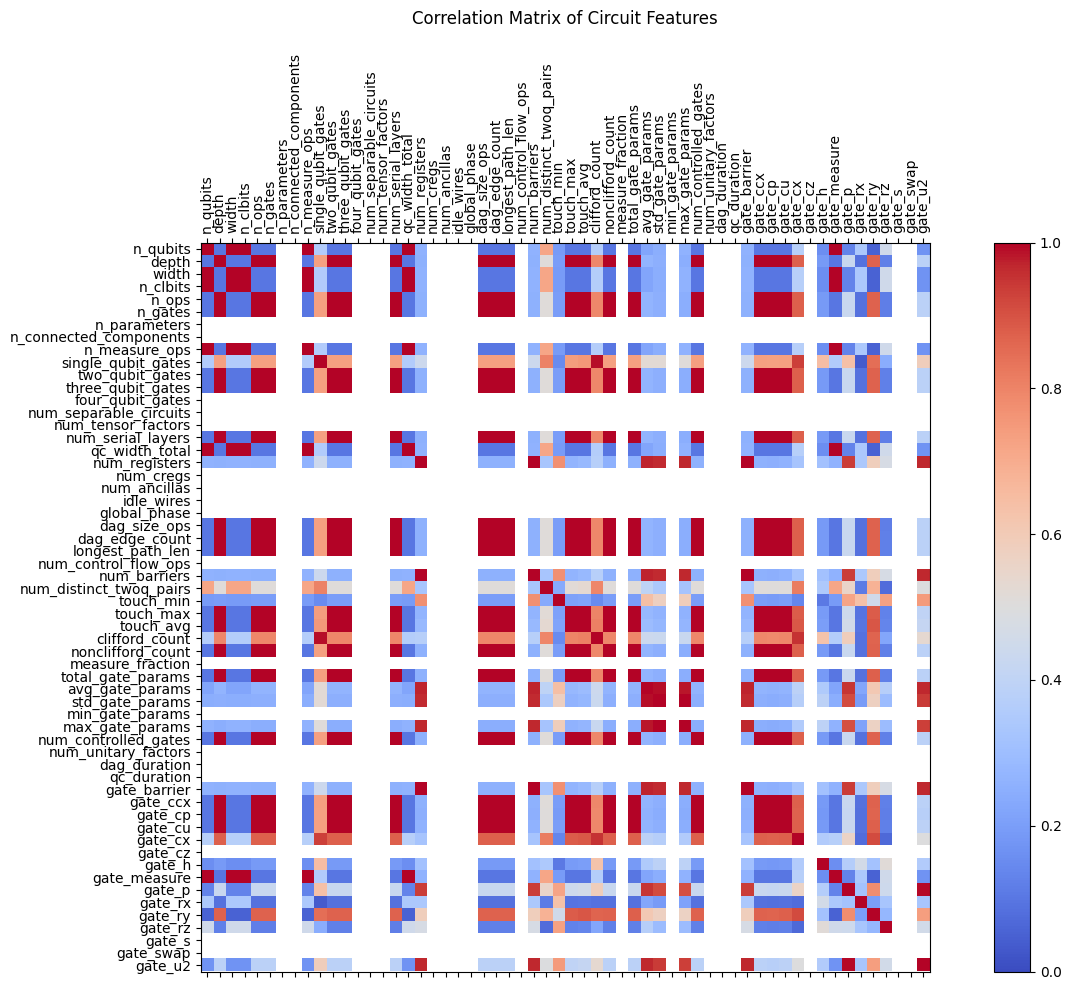


Original features: 58
Reduced features: 29


In [23]:
# Select only circuit-related features
X_circuit = estimate_runtime_df_processed[circuit_features]

# 1. Correlation matrix
corr_matrix = X_circuit.corr().abs()

# 2. Print highly correlated pairs
threshold = 0.95
high_corr_pairs = [
	(i, j, corr_matrix.loc[i, j])
	for i in corr_matrix.columns
	for j in corr_matrix.columns
	if i < j and corr_matrix.loc[i, j] > threshold
]
print("Highly correlated feature pairs (>|{:.2f}|):".format(threshold))
for i, j, corr in sorted(high_corr_pairs, key=lambda x: -x[2]):
	print(f"{i} ↔ {j} : {corr:.3f}")

# (Optional) Heatmap visualization using matplotlib only
fig, ax = plt.subplots(figsize=(14, 10))
cax = ax.matshow(corr_matrix, cmap="coolwarm", vmin=0, vmax=1)
fig.colorbar(cax)
ax.set_xticks(range(len(corr_matrix.columns)))
ax.set_yticks(range(len(corr_matrix.columns)))
ax.set_xticklabels(corr_matrix.columns, rotation=90)
ax.set_yticklabels(corr_matrix.columns)
plt.title("Correlation Matrix of Circuit Features", pad=20)
plt.tight_layout()
plt.show()

# 3. Remove one feature from each highly correlated group
to_drop = set()
for i, j, corr in high_corr_pairs:
	to_drop.add(j)   # drop the second feature arbitrarily

X_circuit_reduced = X_circuit.drop(columns=list(to_drop))

print("\nOriginal features:", X_circuit.shape[1])
print("Reduced features:", X_circuit_reduced.shape[1])


#### In this reduced set of features! What features most impact run_time? --> This is based on estimate_runtime_df.csv
### Feature Selection Problem

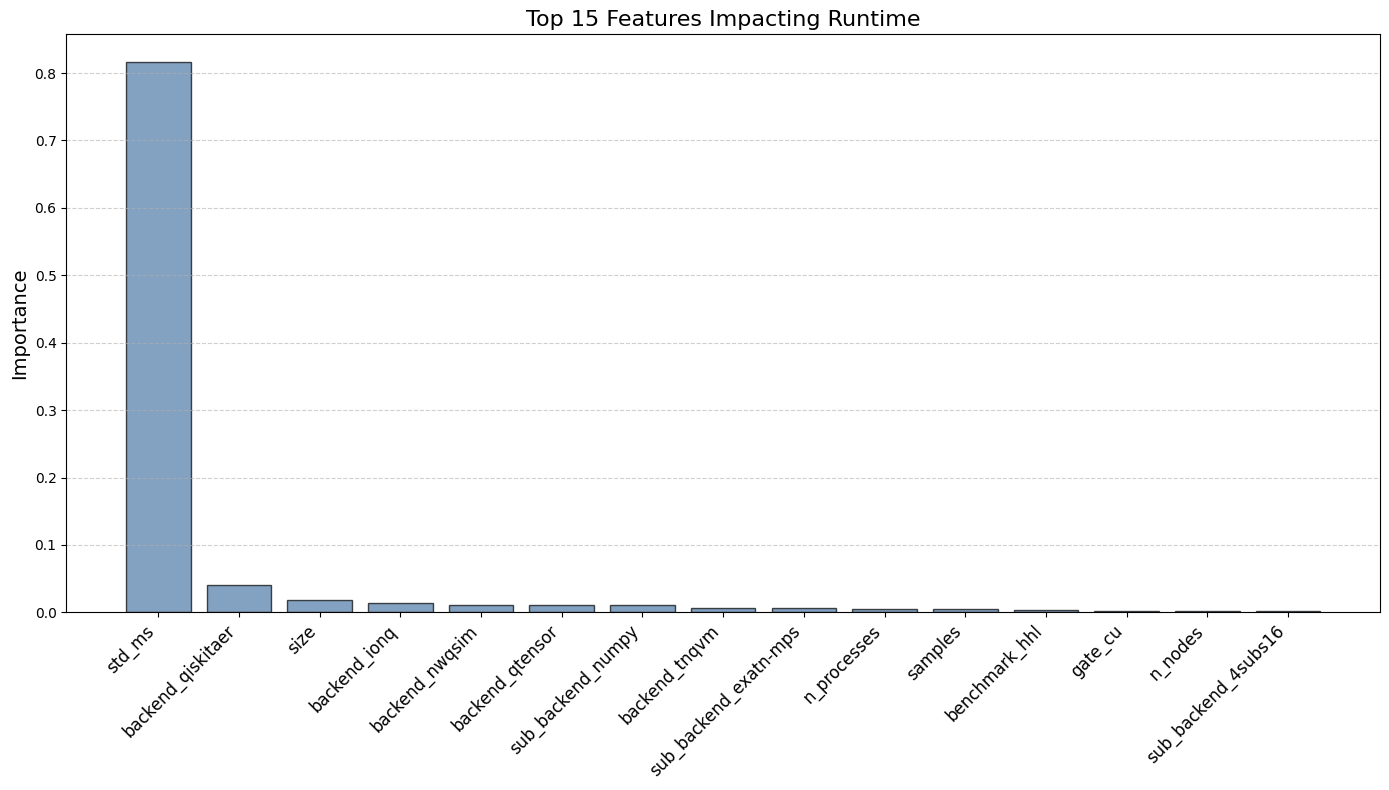

In [25]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import numpy as np


# Target = mean runtime
y = estimate_runtime_df["mean_ms"]

# Features = processed dataframe (drop target if still present)
X = estimate_runtime_df_processed.drop(columns=[
	"mean_ms", "benchmark", "backend", "sub_backend", "device", "run_mode", 
	], errors="ignore")

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Fit a random forest
rf = RandomForestRegressor(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)

# Feature importances
importances = rf.feature_importances_
indices = np.argsort(importances)[::-1]

# Plot top 15
plt.figure(figsize=(14, 8))
plt.bar(range(15), importances[indices[:15]], color=colors[0], edgecolor="black", alpha=0.7)
plt.xticks(range(15), X.columns[indices[:15]], rotation=45, ha="right", fontsize=12)
plt.ylabel("Importance", fontsize=14)
plt.title("Top 15 Features Impacting Runtime", fontsize=16)
plt.grid(True, axis="y", linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()


## Problem 1: Estimate Runtime (Regression Problem)
#### Given all circuit meta data, backend, sub-backend, device, run_mode, n_nodes, n_processes_per_node, estimate how long the run will take!?

## Problem 2: Best Backend (Classification Problem)

### PCA

In [6]:
# have to indentify important columns for scatter matrix
# from best_backend_df.columns.tolist()

all_cols = best_backend_df.columns.tolist()
print("All columns:", all_cols)


All columns: ['benchmark', 'size', 'n_nodes', 'n_processes', 'best_backend', 'best_runtime', 'n_qubits', 'depth', 'width', 'n_clbits', 'n_ops', 'n_gates', 'n_parameters', 'n_connected_components', 'n_measure_ops', 'single_qubit_gates', 'two_qubit_gates', 'three_qubit_gates', 'four_qubit_gates', 'num_separable_circuits', 'num_tensor_factors', 'num_serial_layers', 'qc_width_total', 'num_registers', 'num_cregs', 'num_ancillas', 'idle_wires', 'global_phase', 'dag_size_ops', 'dag_edge_count', 'longest_path_len', 'num_control_flow_ops', 'num_barriers', 'num_distinct_twoq_pairs', 'touch_min', 'touch_max', 'touch_avg', 'clifford_count', 'nonclifford_count', 'measure_fraction', 'total_gate_params', 'avg_gate_params', 'std_gate_params', 'min_gate_params', 'max_gate_params', 'num_controlled_gates', 'num_unitary_factors', 'dag_duration', 'qc_duration', 'gate_barrier', 'gate_ccx', 'gate_cp', 'gate_cu', 'gate_cx', 'gate_cz', 'gate_h', 'gate_measure', 'gate_p', 'gate_rx', 'gate_ry', 'gate_rz', 'gate_

                    feature  importance
4                  n_qubits    0.137488
12            n_measure_ops    0.137488
20           qc_width_total    0.137488
54             gate_measure    0.137488
7                  n_clbits    0.137488
6                     width    0.137488
21            num_registers    0.133934
31  num_distinct_twoq_pairs    0.132941
49                  gate_cp    0.132415
15        three_qubit_gates    0.132235
48                 gate_ccx    0.132235
43     num_controlled_gates    0.132227
5                     depth    0.132225
28         longest_path_len    0.132224
36        nonclifford_count    0.132224
14          two_qubit_gates    0.132223
27           dag_edge_count    0.132221
8                     n_ops    0.132216
9                   n_gates    0.132216
19        num_serial_layers    0.132215
26             dag_size_ops    0.132215
38        total_gate_params    0.132186
50                  gate_cu    0.132173
33                touch_max    0.131723


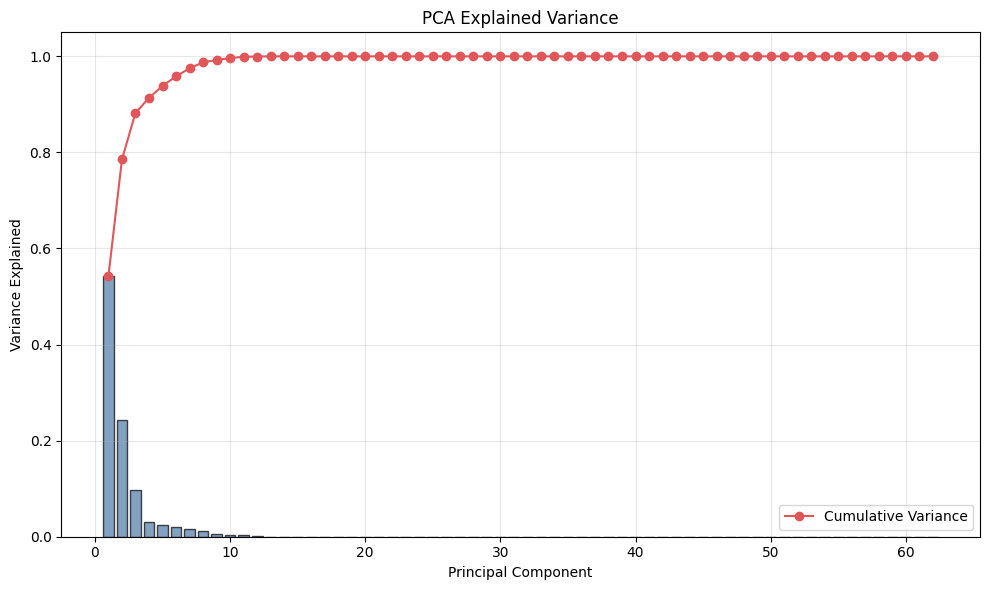

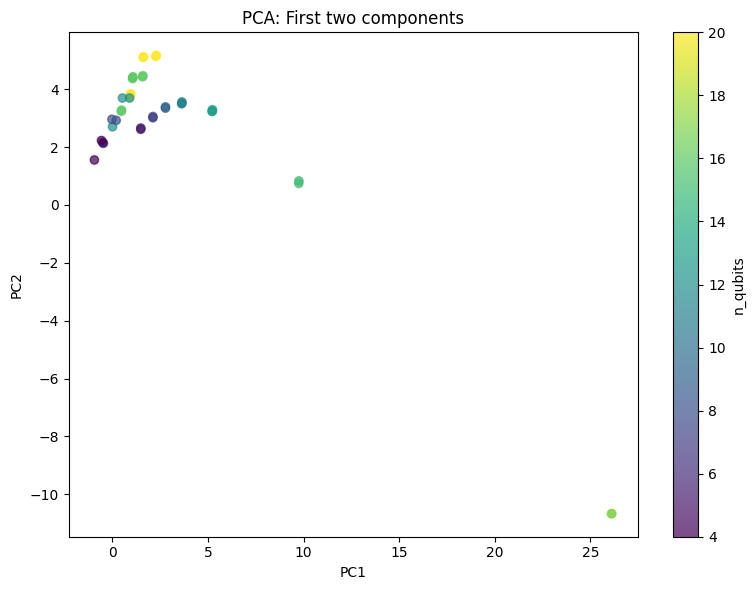

In [7]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import pandas as pd

# --- 1. Choose numeric columns only ---
# drop categorical / identifiers
drop_cols = ["benchmark", "best_backend"]  
num_cols = [c for c in best_backend_df.columns if c not in drop_cols]

X = best_backend_df[num_cols].select_dtypes(include=[np.number]).fillna(0)

# --- 2. Standardize features ---
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# --- 3. PCA ---
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

# Variance explained
explained_var = pca.explained_variance_ratio_
cum_var = np.cumsum(explained_var)

# --- 4. Feature contributions (loadings × variance explained) ---
loadings = pca.components_.T
feature_importance = np.sum(np.abs(loadings) * explained_var, axis=1)
importance_df = pd.DataFrame({
    "feature": num_cols,
    "importance": feature_importance
}).sort_values("importance", ascending=False)

print(importance_df.head(30))  # top contributors

# --- 5. Plot variance explained ---
plt.figure(figsize=(10,6))
plt.bar(range(1, len(explained_var)+1), explained_var, color=colors[0], alpha=0.7, edgecolor="black")
plt.plot(range(1, len(cum_var)+1), cum_var, marker="o", color=colors[2], label="Cumulative Variance")
plt.xlabel("Principal Component")
plt.ylabel("Variance Explained")
plt.title("PCA Explained Variance")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# --- 6. Optional: scatter in PC space ---
plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0], X_pca[:,1], c=best_backend_df["n_qubits"], cmap="viridis", alpha=0.7)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA: First two components")
plt.colorbar(label="n_qubits")
plt.tight_layout()
plt.show()


Explained variance ratio (10 PCs):
[0.54247586 0.24301446 0.09669249 0.0313604  0.02476947 0.02011488
 0.01654096 0.01245617 0.0050373  0.00387488]
Cumulative variance explained: 0.9963368599655795

Top 15 most important features (variance contribution):
                    feature  importance
54             gate_measure    0.137062
12            n_measure_ops    0.137062
20           qc_width_total    0.137062
6                     width    0.137062
4                  n_qubits    0.137062
7                  n_clbits    0.137062
21            num_registers    0.133727
31  num_distinct_twoq_pairs    0.132581
49                  gate_cp    0.132294
15        three_qubit_gates    0.132119
48                 gate_ccx    0.132119
43     num_controlled_gates    0.132113
5                     depth    0.132111
28         longest_path_len    0.132110
14          two_qubit_gates    0.132110


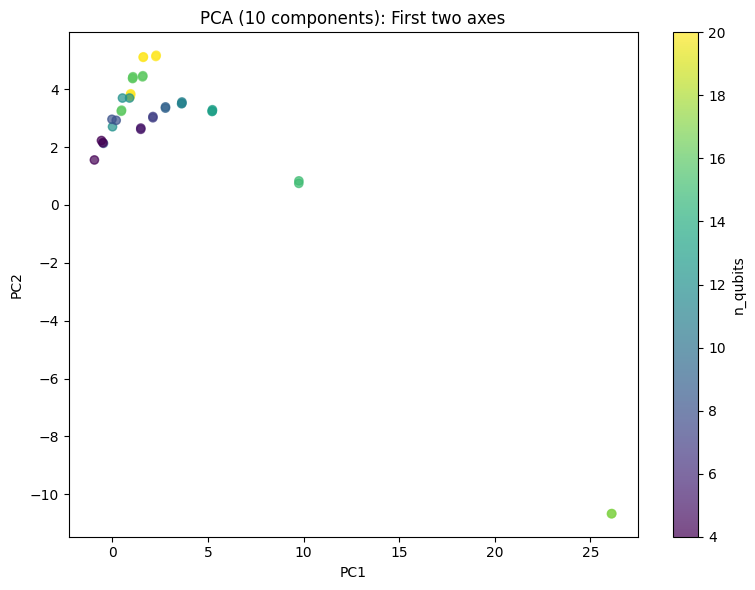

In [8]:
from sklearn.decomposition import PCA

# so we need only 10 components to explain ~99% variance.
m = 10

# --- Fit PCA with m components ---
pca_m = PCA(n_components=m)
X_pca_m = pca_m.fit_transform(X_scaled)

# --- Variance explained by these m components ---
print("Explained variance ratio (10 PCs):")
print(pca_m.explained_variance_ratio_)
print("Cumulative variance explained:", np.sum(pca_m.explained_variance_ratio_))

# --- Map back to original features ---
loadings_m = pca_m.components_.T  # shape: [n_features, m]

# Importance score = variance-weighted contribution across the 10 PCs
feature_importance_m = np.sum(np.abs(loadings_m) * pca_m.explained_variance_ratio_, axis=1)

importance_df_m = pd.DataFrame({
    "feature": num_cols,
    "importance": feature_importance_m
}).sort_values("importance", ascending=False)

print("\nTop 15 most important features (variance contribution):")
print(importance_df_m.head(15))

# --- Optional: Scatter plot in the new PC space ---
plt.figure(figsize=(8,6))
plt.scatter(X_pca_m[:,0], X_pca_m[:,1], c=best_backend_df["n_qubits"], cmap="viridis", alpha=0.7)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA (10 components): First two axes")
plt.colorbar(label="n_qubits")
plt.tight_layout()
plt.show()


### Some corelation analysis and visualizations here ###

/lustre/orion/gen008/proj-shared/qhpc/srikar/qfw_related/results_analysis/jupyter_notebooks/.venv/lib64/python3.11/site-packages/pandas/plotting/_matplotlib/misc.py:100: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  ax.set_xlim(boundaries_list[j])
/lustre/orion/gen008/proj-shared/qhpc/srikar/qfw_related/results_analysis/jupyter_notebooks/.venv/lib64/python3.11/site-packages/pandas/plotting/_matplotlib/misc.py:101: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  ax.set_ylim(boundaries_list[i])
/lustre/orion/gen008/proj-shared/qhpc/srikar/qfw_related/results_analysis/jupyter_notebooks/.venv/lib64/python3.11/site-packages/pandas/plotting/_matplotlib/misc.py:91: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  ax.set_xlim(boundaries_list[i])


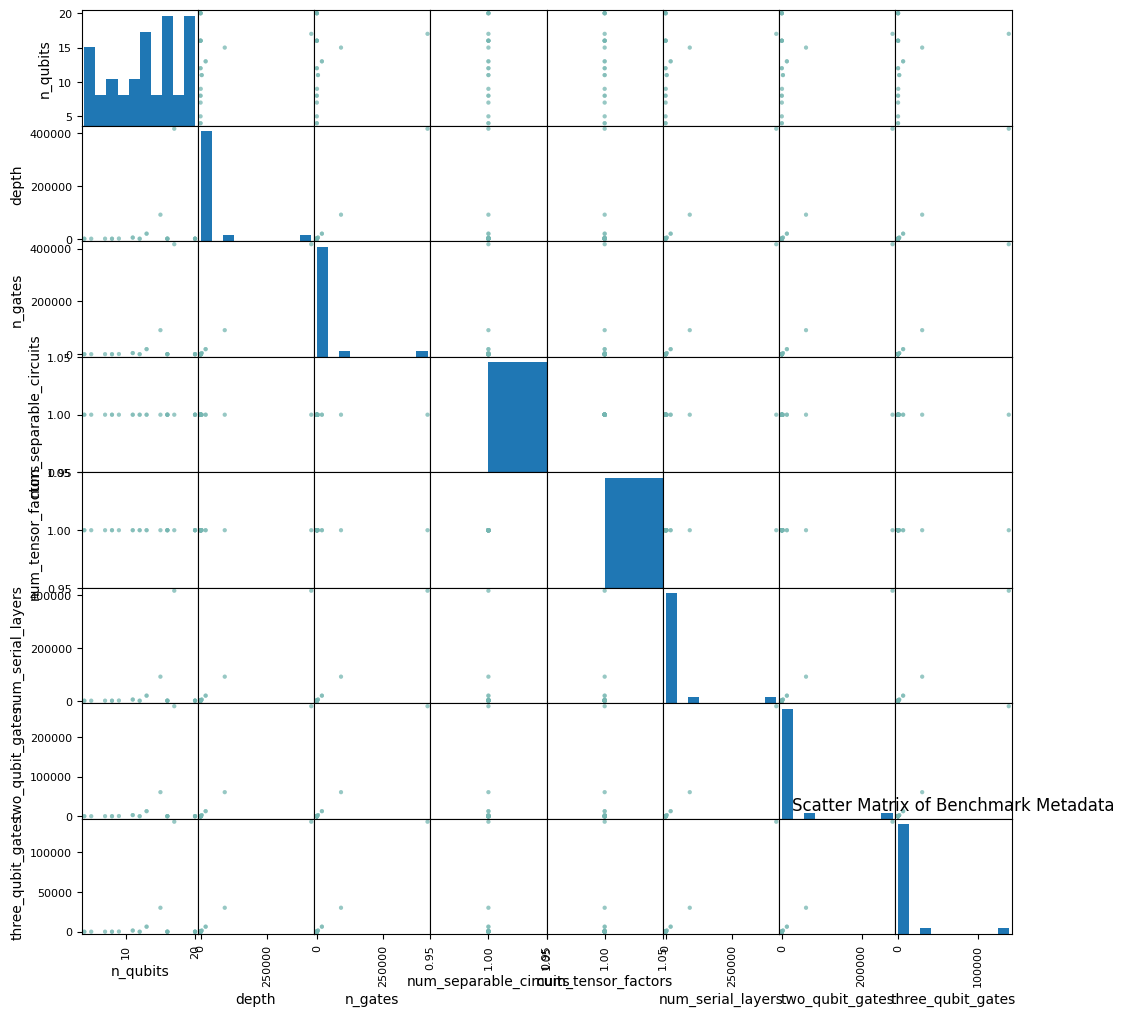

In [9]:
from pandas.plotting import scatter_matrix

# Select important columns for scatter matrix from above! after PCA!
important_cols = [ # ?? we want to choose after PCA actually.
	'n_qubits', 'depth', 'n_gates', 'num_separable_circuits', 'num_tensor_factors',
	'num_serial_layers',
	'singe_qubit_gates', 'two_qubit_gates', 'three_qubit_gates',
]

meta_cols = [c for c in important_cols if c in best_backend_df.columns and pd.api.types.is_numeric_dtype(best_backend_df[c])]

if len(meta_cols) < 2:
	print("[warn] Need at least two columns for scatter matrix.")
else:
	axes = scatter_matrix(
		best_backend_df[meta_cols],
		figsize=(12, 12),
		color=colors[3]
	)
	plt.title("Scatter Matrix of Benchmark Metadata")
	plt.show()
	plt.close()

### Basic K-nearest-neighbors clustering?